In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
from scipy import stats



In [2]:
import pandas as pd

df = pd.read_csv("../data/outputs/provider_month.csv")
df

,billing_provider_npi,cohort_label,month,paid_t,claims_t,hcpcs_count_t,paid_per_claim_t,top_code_paid_share,top_3_code_paid_share,hcpcs_entropy,hcpcs_hhi,beneficiaries_proxy_t,claims_per_beneficiary_proxy_t,paid_per_beneficiary_proxy_t,label,excldate
0,1003006180,NV_organization,2018-01-01,671415.34,6610,7,101.575694,0.749187,0.934509,0.911755,0.580282,5498,1.202255,122.119924,0,NaN
1,1003006180,NV_organization,2018-02-01,509838.42,5053,7,100.898163,0.683650,0.915130,1.079675,0.496263,4268,1.183927,119.456050,0,NaN
2,1003006180,NV_organization,2018-03-01,516444.10,5386,7,95.886391,0.671772,0.898001,1.129894,0.479706,4597,1.171634,112.343724,0,NaN
3,1003006180,NV_organization,2018-04-01,563348.08,5796,7,97.196011,0.616892,0.903758,1.202937,0.426552,4890,1.185276,115.204106,0,NaN
4,1003006180,NV_organization,2018-05-01,562713.35,5758,7,97.727223,0.619411,0.894353,1.219314,0.425726,4798,1.200083,117.280815,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164844,1992920698,NV_organization,2024-08-01,4669.22,31,1,150.620000,1.000000,1.000000,0.000000,1.000000,31,1.000000,150.620000,0,NaN
164845,1992920698,NV_organization,2024-09-01,5572.94,37,1,150.620000,1.000000,1.000000,0.000000,1.000000,37,1.000000,150.620000,0,NaN
164846,1992920698,NV_organization,2024-10-01,5874.18,39,1,150.620000,1.000000,1.000000,0.000000,1.000000,39,1.000000,150.620000,0,NaN
164847,1992920698,NV_organization,2024-11-01,5723.56,43,1,133.106047,1.000000,1.000000,0.000000,1.000000,38,1.131579,150.620000,0,NaN


## tsfresh: Automated Time-Series Feature Extraction

### How it works

tsfresh operates on **long-format time-series data** — it needs multiple rows per entity (provider), one per time step (month).  That is the `provider_month.csv` file, **not** the provider-level `df` above which already has one collapsed row per provider.

**Input contract:**
| parameter | this notebook |
|---|---|
| `column_id` | `billing_provider_npi` — groups rows into one time series per provider |
| `column_sort` | `month` — orders observations within each provider |
| value columns | every numeric monthly metric (`paid_t`, `claims_t`, `hcpcs_count_t`, `paid_per_claim_t`, `hcpcs_entropy`, `hcpcs_hhi`, `beneficiaries_proxy_t`, …) |

For each **(provider, value_column)** pair, tsfresh computes ~800 statistics covering:
- **Distributional**: mean, std, kurtosis, skew, quantiles
- **Temporal structure**: autocorrelation, partial autocorrelation, linear trend slope/intercept/stderr
- **Complexity**: approximate entropy, sample entropy, Lempel-Ziv
- **Signal shape**: number of peaks, zero-crossings, FFT coefficients, continuous wavelet coefficients

**Parameter sets** (speed vs. completeness tradeoff):
- `MinimalFCParameters` — ~10 features/column, seconds. Good for smoke-testing.
- `EfficientFCParameters` — ~800 features/column, skips the very slow calculators. **Default choice here.**
- `ComprehensiveFCParameters` — 1200+ features/column, can take hours on large data.

**Feature selection** (`select_features`): runs a Benjamini-Hochberg-corrected hypothesis test (KS / Mann-Whitney) per feature against the binary label. Only features with a statistically significant distributional shift between label=0 and label=1 survive. This dramatically reduces dimensionality before modelling.

> **Proxy note:** `beneficiaries_proxy_t`, `claims_per_beneficiary_proxy_t`, and `paid_per_beneficiary_proxy_t` are summed across HCPCS codes and can double-count the same beneficiary. tsfresh will still extract valid temporal-pattern features from them (trends, autocorrelation, etc.) — just do not interpret the raw magnitudes as true per-patient counts.


In [ ]:
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters, MinimalFCParameters

# ── 1. Load raw provider-month time series ────────────────────────────────────
pm = pd.read_csv("../data/outputs/provider_month.csv", parse_dates=["month"])
print(f"provider_month shape: {pm.shape}")

# ── 2. Identify time-series value columns ─────────────────────────────────────
NON_SERIES_COLS = {
    "billing_provider_npi", "cohort_label", "month",
    "label", "excldate", "insufficient_history_flag",
    "top_code_paid_share", "top_3_code_paid_share",
}
ts_value_cols = [
    c for c in pm.columns
    if c not in NON_SERIES_COLS and pd.api.types.is_numeric_dtype(pm[c])
]
print(f"Time-series value columns ({len(ts_value_cols)}): {ts_value_cols}")

# ── 3. Build tsfresh-format input ─────────────────────────────────────────────
ts_input = pm[["billing_provider_npi", "month"] + ts_value_cols].copy()

# ── 4. Per-provider binary labels ─────────────────────────────────────────────
y_series = (
    pm.groupby("billing_provider_npi")["label"]
    .max()
    .dropna()
    .astype(int)
)
ts_input = ts_input[ts_input["billing_provider_npi"].isin(y_series.index)]
print(f"\nProviders in ts_input : {ts_input['billing_provider_npi'].nunique()}")
print(f"  label=1 (excluded)  : {(y_series == 1).sum()}")
print(f"  label=0 (normal)    : {(y_series == 0).sum()}")

# ── 5. Build feature calculator settings ─────────────────────────────────────
# Start from EfficientFCParameters and remove binned_entropy.
# binned_entropy builds a numpy histogram per individual provider series —
# it crashes with "Too many bins for data range" whenever a provider's series
# is constant (e.g. always hcpcs_entropy=0).  Global variance filtering does
# NOT catch this because the column is non-constant across the whole dataset.
fc_params = EfficientFCParameters()
fc_params.pop("binned_entropy", None)

# ── 6. Extract features ───────────────────────────────────────────────────────
print("\nExtracting tsfresh features — this may take several minutes …")
extracted = extract_features(
    ts_input,
    column_id="billing_provider_npi",
    column_sort="month",
    default_fc_parameters=fc_params,
    n_jobs=0,
    impute_function=impute,
    show_warnings=False,
)
print(f"\nExtracted shape: {extracted.shape}  "
      f"({extracted.shape[0]} providers × {extracted.shape[1]} raw features)")

# ── 7. Statistical feature selection ─────────────────────────────────────────
y_aligned = y_series.loc[extracted.index]
selected = select_features(extracted, y_aligned, fdr_level=0.05)
print(f"Features surviving BH correction (fdr=0.05): {selected.shape[1]} / {extracted.shape[1]}")

selected.head(3)

In [14]:
extracted_with_label = extracted.join(y_aligned.rename("label"))
extracted_with_label

,paid_t__sum_values,paid_t__median,paid_t__mean,paid_t__length,paid_t__standard_deviation,paid_t__variance,paid_t__root_mean_square,paid_t__maximum,paid_t__absolute_maximum,paid_t__minimum,...,paid_per_beneficiary_proxy_t__median,paid_per_beneficiary_proxy_t__mean,paid_per_beneficiary_proxy_t__length,paid_per_beneficiary_proxy_t__standard_deviation,paid_per_beneficiary_proxy_t__variance,paid_per_beneficiary_proxy_t__root_mean_square,paid_per_beneficiary_proxy_t__maximum,paid_per_beneficiary_proxy_t__absolute_maximum,paid_per_beneficiary_proxy_t__minimum,label
1003006180,34891367.71,450735.470,415373.425119,84.0,128076.891851,1.640369e+10,434670.878391,671415.34,671415.34,108427.37,...,116.550889,115.397937,84.0,6.040274,36.484914,115.555911,128.164740,128.164740,90.762654,0
1003011313,21237.93,671.000,732.342414,29.0,396.660798,1.573398e+05,832.865655,1903.31,1903.31,272.34,...,31.837368,36.536127,29.0,14.678285,215.452041,39.374365,86.182000,86.182000,12.856400,0
1003023508,216665.52,6145.395,6372.515294,34.0,3372.567226,1.137421e+07,7209.934873,12102.76,12102.76,989.04,...,128.366533,140.331893,34.0,48.268895,2329.886202,148.401235,232.745385,232.745385,63.193333,0
1003069485,44700.48,44700.480,44700.480000,1.0,0.000000,0.000000e+00,44700.480000,44700.48,44700.48,44700.48,...,3725.040000,3725.040000,1.0,0.000000,0.000000,3725.040000,3725.040000,3725.040000,3725.040000,0
1003086273,495386.50,6872.200,6605.153333,75.0,3333.746572,1.111387e+07,7398.778059,14150.31,14150.31,767.14,...,38.908605,39.286789,75.0,9.491433,90.087296,40.417064,65.450882,65.450882,17.675000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992842660,5428653.73,73425.950,67020.416420,81.0,28780.270862,8.283040e+08,72938.605744,111456.49,111456.49,5797.77,...,55.881823,55.576425,81.0,12.505570,156.389274,56.966027,75.768425,75.768425,30.717701,0
1992886584,1971.00,241.500,328.500000,6.0,146.219869,2.138025e+04,359.572663,609.00,609.00,220.00,...,18.011667,18.173120,6.0,1.038678,1.078851,18.202778,20.000000,20.000000,16.923077,0
1992888283,40607.21,910.575,966.838333,42.0,478.749538,2.292011e+05,1078.877881,2071.88,2071.88,26.86,...,47.885192,47.343669,42.0,18.241585,332.755417,50.736362,83.083333,83.083333,2.238333,0
1992919237,464911.37,5355.250,5534.659167,84.0,3263.447444,1.065009e+07,6425.149127,12198.57,12198.57,507.59,...,16.523474,16.543016,84.0,6.371464,40.595554,17.727575,35.773092,35.773092,4.958750,0


In [16]:
from sklearn.metrics import roc_auc_score

df_ts = extracted_with_label
features_ts = [col for col in df_ts.columns if col != "label"]

rows = []
for feat in features_ts:
    valid = df_ts[["label", feat]].dropna()
    if valid["label"].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(valid["label"], valid[feat])
        auc = max(auc, 1 - auc)
        rows.append({"feature": feat, "auroc": round(auc, 4)})
    except Exception:
        continue

auroc_ts = pd.DataFrame(rows).sort_values("auroc", ascending=False).reset_index(drop=True)
auroc_ts.head(10)

,feature,auroc
0,paid_per_beneficiary_proxy_t__standard_deviation,0.8841
1,paid_per_beneficiary_proxy_t__variance,0.8841
2,paid_per_beneficiary_proxy_t__absolute_maximum,0.8607
3,paid_per_beneficiary_proxy_t__maximum,0.8607
4,paid_per_beneficiary_proxy_t__root_mean_square,0.8522
5,paid_t__standard_deviation,0.8486
6,paid_t__variance,0.8486
7,paid_per_beneficiary_proxy_t__mean,0.8444
8,paid_per_beneficiary_proxy_t__median,0.8373
9,paid_t__root_mean_square,0.8369


/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


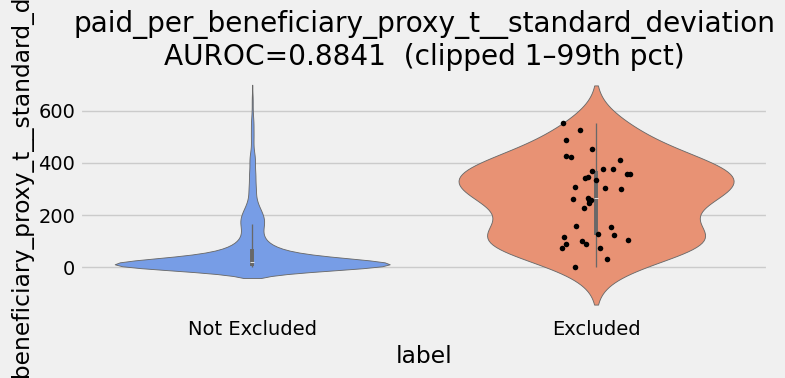

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


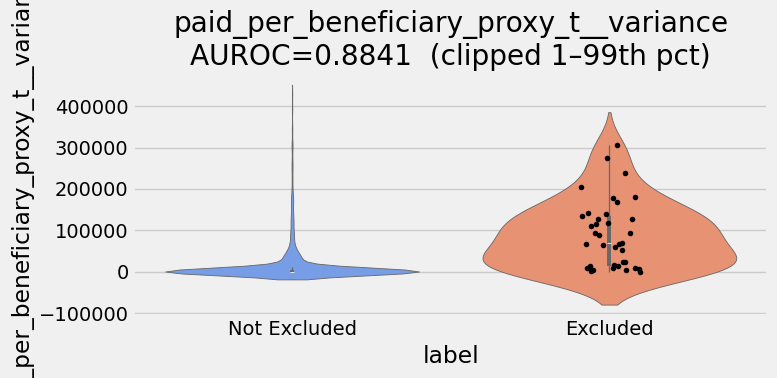

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


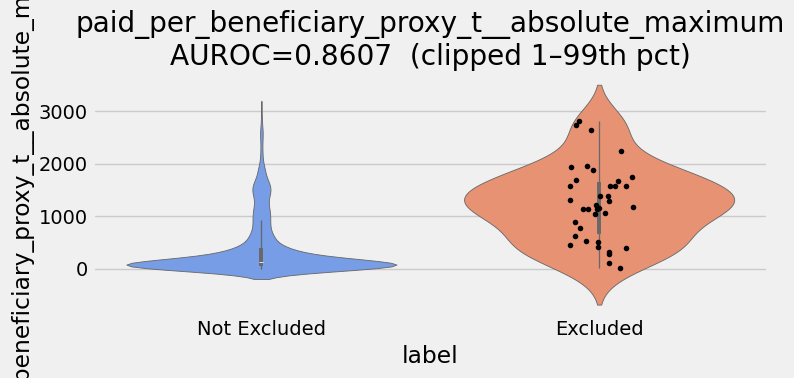

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


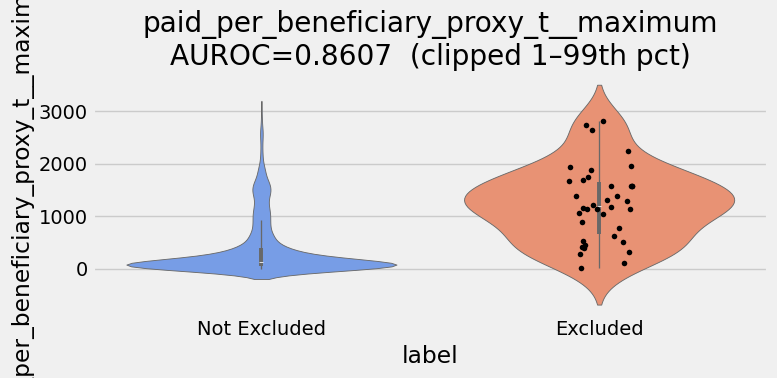

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


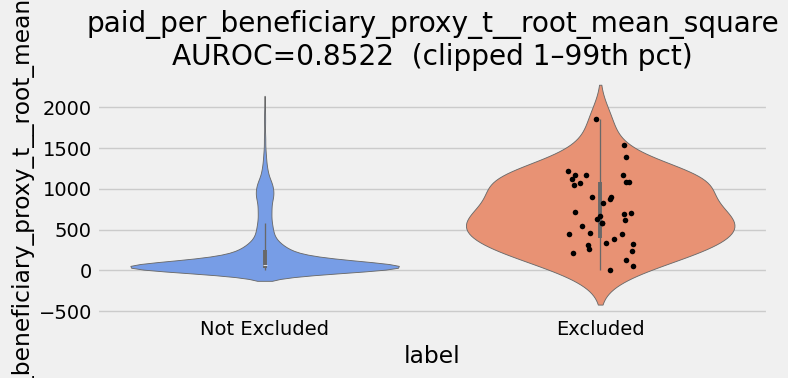

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


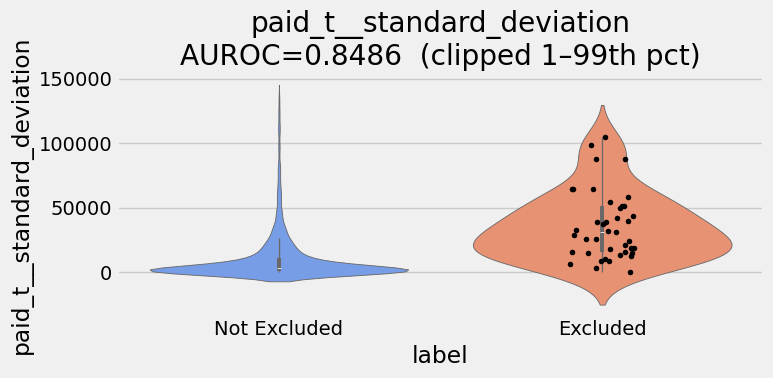

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


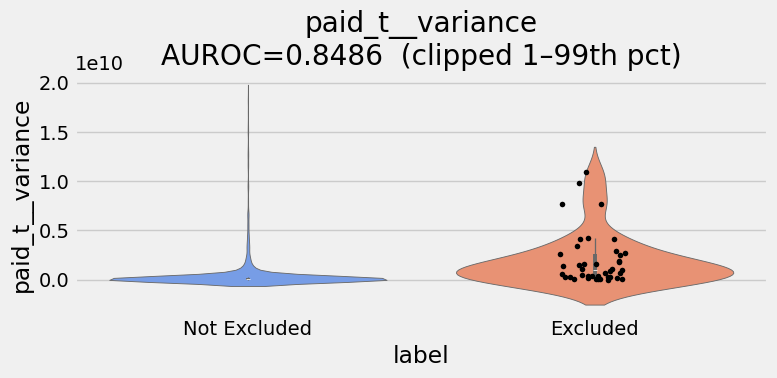

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


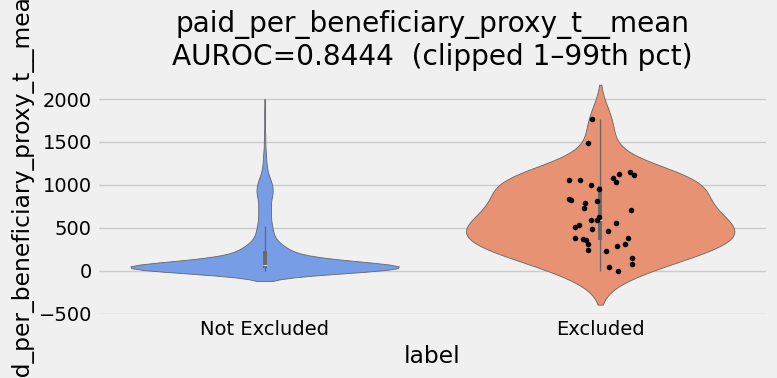

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


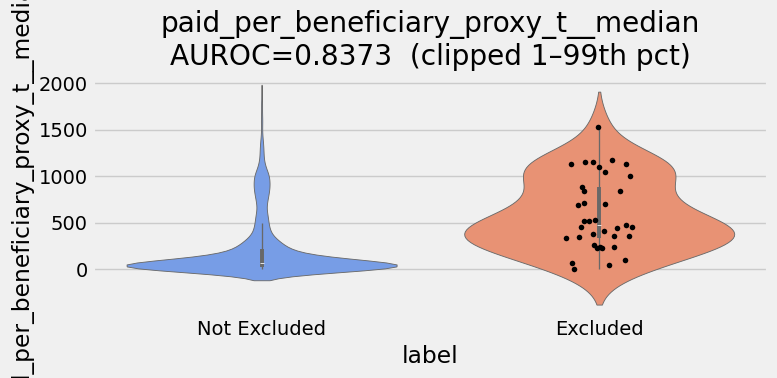

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


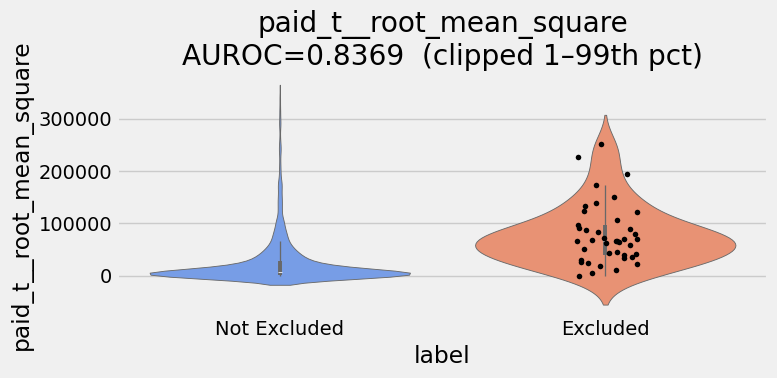

In [17]:
top10 = auroc_ts.head(10)["feature"].tolist()

for feat in top10:
    fig, ax = plt.subplots(figsize=(8, 4))
    q01 = df_ts[feat].quantile(0.01)
    q99 = df_ts[feat].quantile(0.99)
    plot_df = df_ts[df_ts[feat].between(q01, q99)]
    auc_val = auroc_ts.loc[auroc_ts["feature"] == feat, "auroc"].values[0]

    sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
    sns.stripplot(data=plot_df[plot_df["label"] == 1], x="label", y=feat, ax=ax, color="black", size=4, jitter=True)
    ax.set_title(f"{feat}\nAUROC={auc_val}  (clipped 1–99th pct)")
    ax.set_xticklabels(["Not Excluded", "Excluded"])
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.ensemble import IsolationForest

# selected_with_label: index=billing_provider_npi, columns=tsfresh selected features + label
features_iso = [col for col in selected_with_label.columns if col != "label"]

X = selected_with_label[features_iso].dropna()
idx = X.index  # billing_provider_npi values

iso = IsolationForest(random_state=42)
iso.fit(X)
scores = -iso.score_samples(X)  # higher = more anomalous

results = selected_with_label.loc[idx, ["label"]].copy()
results.index.name = "billing_provider_npi"
results = results.reset_index()
results["anomaly_score"] = scores
results = results.sort_values("anomaly_score", ascending=False).reset_index(drop=True)

base_rate = results["label"].mean()
print(f"Base rate (LEIE prevalence): {base_rate:.4f}")

for k in [50, 100, 200, 500]:
    top_k = results.head(k)
    hits = top_k["label"].sum()
    precision_k = hits / k
    lift = precision_k / base_rate if base_rate > 0 else float("nan")
    print(f"Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")